In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

DATASET_ROOT = "/content/drive/MyDrive/CompostDataset"

IMAGE_DIR = os.path.join(DATASET_ROOT, "images")
MASK_DIR = os.path.join(DATASET_ROOT, "masks")

print("Images:", len(os.listdir(IMAGE_DIR)))
print("Masks:", len(os.listdir(MASK_DIR)))


Images: 199
Masks: 199


In [ ]:
!pip install -q --upgrade segmentation-models-pytorch timm albumentations==1.3.0

In [ ]:
import segmentation_models_pytorch as smp
import timm
import albumentations as A
import torch

print("torch", torch.__version__)
print("smp", smp.__version__)
print("timm", timm.__version__)
print("albumentations", A.__version__)
print("CUDA available?", torch.cuda.is_available())


torch 2.9.0+cu126
smp 0.5.0
timm 1.0.22
albumentations 1.3.0
CUDA available? True


In [ ]:
# 2) Imports
import os
from glob import glob
from pathlib import Path
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

In [ ]:
# 3) Configuration 
DATASET_ROOT = "/content/drive/MyDrive/CompostDataset"  
IMAGE_DIR = os.path.join(DATASET_ROOT, "images")
MASK_DIR  = os.path.join(DATASET_ROOT, "masks")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_SIZE = 512           
BATCH_SIZE = 8
NUM_WORKERS = 2
ENCODER = "resnet34"
ENCODER_WEIGHTS = "imagenet"
ARCH = "Unet"
LOSS_BCE_WEIGHT = 1.0
FREEZE_EPOCHS = 10         # epochs while encoder frozen
UNFREEZE_EPOCHS = 20       # epochs after unfreezing
LR = 1e-3
WEIGHT_DECAY = 1e-5
CHECKPOINT_DIR = "/content/drive/MyDrive/Compost_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def make_pairs(image_dir, mask_dir):
    image_paths = sorted(glob(os.path.join(image_dir, "*")))
    mask_paths = sorted(glob(os.path.join(mask_dir, "*")))
    # attempt match by filename stem
    img_map = {Path(p).stem: p for p in image_paths}
    mask_map = {Path(p).stem: p for p in mask_paths}
    common = sorted(set(img_map.keys()).intersection(mask_map.keys()))
    pairs = [(img_map[k], mask_map[k]) for k in common]
    if len(pairs) == 0:
        raise RuntimeError("No matching image/mask pairs found. Check filenames.")
    print(f"Found {len(pairs)} image-mask pairs.")
    return pairs

pairs = make_pairs(IMAGE_DIR, MASK_DIR)

Found 199 image-mask pairs.


In [ ]:
class CompostSegDataset(Dataset):
    def __init__(self, pairs, transforms=None):
        """
        pairs: list of (img_path, mask_path)
        transforms: albumentations transform
        """
        self.pairs = pairs
        self.transforms = transforms

    def __len__(self):
        return len(self.pairs)

    def read_mask(self, path):
        import cv2
        m = cv2.imread(path, cv2.IMREAD_UNCHANGED)  
        if m is None:
            raise RuntimeError(f"Failed to read mask {path}")

        if m.ndim == 3:
            fg = (m.sum(axis=2) > 0).astype('uint8')
        else:
            # for single-channel masks, convert >0 to 1
            fg = (m > 0).astype('uint8')
        return fg 

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        import cv2
        img = cv2.imread(img_path)
        if img is None:
            raise RuntimeError(f"Failed to read image {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = self.read_mask(mask_path)  

        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img = augmented['image']      
            mask = augmented['mask']     
        else:
            # fallback conversions
            img = TF.to_tensor(img).float()
            mask = torch.from_numpy(mask).float()


        if isinstance(mask, torch.Tensor):
            if mask.dim() == 2:
                mask = mask.unsqueeze(0)
            elif mask.dim() == 3 and mask.shape[0] != 1:
                # just in case mask is CxHxW with C>1: reducing to single channel by any non-zero
                mask = (mask.sum(dim=0) > 0).float().unsqueeze(0)
            mask = mask.float()
        else:
            # if albumentations returned numpy
            mask = torch.from_numpy(np.array(mask)).float()
            if mask.dim() == 2:
                mask = mask.unsqueeze(0)

       
        mask = (mask > 0.5).float()

        return img, mask


In [ ]:
# 6) Albumentations transforms (train/val)
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

valid_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

In [ ]:
# 7) Split dataset
random.seed(42)
indices = list(range(len(pairs)))
random.shuffle(indices)
valid_ratio = 0.15
n_valid = max(1, int(len(indices)*valid_ratio))
valid_idx = indices[:n_valid]
train_idx = indices[n_valid:]

train_pairs = [pairs[i] for i in train_idx]
valid_pairs = [pairs[i] for i in valid_idx]

train_ds = CompostSegDataset(train_pairs, transforms=train_transform)
valid_ds = CompostSegDataset(valid_pairs, transforms=valid_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train samples:", len(train_ds), "Val samples:", len(valid_ds))

Train samples: 170 Val samples: 29


In [ ]:
# 8) Model, loss, metrics
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=3,
    classes=1,            
    activation=None      
)
model.to(DEVICE)

bce = nn.BCEWithLogitsLoss()

dice_loss = smp.losses.DiceLoss(mode='binary')

def combined_loss(outputs, targets):
    loss_bce = bce(outputs, targets)
    loss_dice = dice_loss(outputs, targets)
    return LOSS_BCE_WEIGHT*loss_bce + loss_dice

# Metrics: IoU and Dice coefficient
def sigmoid(x):
    return torch.sigmoid(x)

def batch_iou(outputs, targets, thr=0.5, eps=1e-7):
    # outputs logits
    probs = sigmoid(outputs)
    preds = (probs > thr).float()
    targets = targets.float()
    inter = (preds * targets).sum((1,2,3))
    union = (preds + targets).sum((1,2,3)) - inter
    iou = (inter + eps) / (union + eps)
    return iou.mean().item()

def batch_dice(outputs, targets, thr=0.5, eps=1e-7):
    probs = sigmoid(outputs)
    preds = (probs > thr).float()
    targets = targets.float()
    inter = (preds * targets).sum((1,2,3))
    denom = preds.sum((1,2,3)) + targets.sum((1,2,3))
    dice = (2*inter + eps) / (denom + eps)
    return dice.mean().item()

In [ ]:
# 9) Optimizer & scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [ ]:
# Freeze encoder function
def set_encoder_grad(model, requires_grad: bool):
    for param in model.encoder.parameters():
        param.requires_grad = requires_grad

In [ ]:
batch = next(iter(train_loader))
imgs, masks = batch
print("imgs.shape:", imgs.shape)   # expected (B,3,H,W)
print("masks.shape:", masks.shape) # expected (B,1,H,W)
print("masks min/max:", masks.min().item(), masks.max().item(), "dtype:", masks.dtype)


imgs.shape: torch.Size([8, 3, 512, 512])
masks.shape: torch.Size([8, 1, 512, 512])
masks min/max: 0.0 1.0 dtype: torch.float32


In [ ]:
# 11) Training/eval loops
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    n = 0
    for imgs, masks in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)  # logits
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        running_iou += batch_iou(outputs.detach().cpu(), masks.detach().cpu()) * imgs.size(0)
        running_dice += batch_dice(outputs.detach().cpu(), masks.detach().cpu()) * imgs.size(0)
        n += imgs.size(0)
    return running_loss / n, running_iou / n, running_dice / n

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    n = 0
    for imgs, masks in tqdm(loader, desc="Val", leave=False):
        imgs = imgs.to(device)
        masks = masks.to(device)
        outputs = model(imgs)
        loss = combined_loss(outputs, masks)
        running_loss += loss.item() * imgs.size(0)
        running_iou += batch_iou(outputs.detach().cpu(), masks.detach().cpu()) * imgs.size(0)
        running_dice += batch_dice(outputs.detach().cpu(), masks.detach().cpu()) * imgs.size(0)
        n += imgs.size(0)
    return running_loss / n, running_iou / n, running_dice / n


In [ ]:
# 12) Training schedule: Freeze encoder first
best_val_iou = 0.0
start_epoch = 0

# Freeze encoder
set_encoder_grad(model, False)
print("Encoder frozen. Training only decoder + head.")

for epoch in range(start_epoch, FREEZE_EPOCHS):
    print(f"=== Frozen Phase Epoch {epoch+1}/{FREEZE_EPOCHS} ===")
    tr_loss, tr_iou, tr_dice = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_iou, val_dice = validate(model, valid_loader, DEVICE)
    scheduler.step(val_iou)
    print(f"Train loss {tr_loss:.4f} IoU {tr_iou:.4f} Dice {tr_dice:.4f}")
    print(f"Val   loss {val_loss:.4f} IoU {val_iou:.4f} Dice {val_dice:.4f}")
    # save best
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        save_path = os.path.join(CHECKPOINT_DIR, f"best_frozen_epoch{epoch+1}_iou{val_iou:.4f}.pth")
        torch.save({'epoch': epoch+1, 'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict()}, save_path)
        print("Saved:", save_path)


Encoder frozen. Training only decoder + head.
=== Frozen Phase Epoch 1/10 ===


Train loss 0.5407 IoU 0.8122 Dice 0.8711
Val   loss 0.3404 IoU 0.8567 Dice 0.9222
Saved: /content/drive/MyDrive/Compost_checkpoints/best_frozen_epoch1_iou0.8567.pth
=== Frozen Phase Epoch 2/10 ===


Train loss 0.1539 IoU 0.9531 Dice 0.9759
Val   loss 0.1022 IoU 0.9633 Dice 0.9812
Saved: /content/drive/MyDrive/Compost_checkpoints/best_frozen_epoch2_iou0.9633.pth
=== Frozen Phase Epoch 3/10 ===


Train loss 0.0808 IoU 0.9647 Dice 0.9820
Val   loss 0.0645 IoU 0.9720 Dice 0.9856
Saved: /content/drive/MyDrive/Compost_checkpoints/best_frozen_epoch3_iou0.9720.pth
=== Frozen Phase Epoch 4/10 ===


Train loss 0.0593 IoU 0.9674 Dice 0.9833
Val   loss 0.0500 IoU 0.9746 Dice 0.9870
Saved: /content/drive/MyDrive/Compost_checkpoints/best_frozen_epoch4_iou0.9746.pth
=== Frozen Phase Epoch 5/10 ===


Train loss 0.0526 IoU 0.9685 Dice 0.9839
Val   loss 0.0456 IoU 0.9742 Dice 0.9868
=== Frozen Phase Epoch 6/10 ===


KeyboardInterrupt: 

In [ ]:
# CONFIG
CHECKPOINT_DIR = "/content/drive/MyDrive/Compost_checkpoints"  # where your best_frozen_*.pth are
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ENCODER = "resnet34"
IMAGE_SIZE = 512
UNFREEZE_EPOCHS = 7
LR = 1e-3        
FINETUNE_LR = LR * 0.2
WEIGHT_DECAY = 1e-5
EARLY_STOP_PATIENCE = 3
BATCH_SIZE = 8    
SAVE_DIR = CHECKPOINT_DIR

from google.colab import drive
drive.mount('/content/drive', force_remount=True)


import os, glob, re
all_ckpts = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "best_frozen_*.pth")))
if len(all_ckpts) == 0:
    raise FileNotFoundError(f"No best_frozen_*.pth found in {CHECKPOINT_DIR}. Check path.")
# choose the checkpoint with largest IoU by parsing filename "iouX.XXXX"
def parse_iou(fn):
    m = re.search(r"iou([0-9]+\.[0-9]+)", fn)
    return float(m.group(1)) if m else 0.0
best_ckpt = max(all_ckpts, key=parse_iou)
print("Using checkpoint:", best_ckpt)

import segmentation_models_pytorch as smp
import torch, torch.nn as nn

model = smp.Unet(encoder_name=ENCODER, encoder_weights=None, in_channels=3, classes=1, activation=None)
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model = model.to(DEVICE)
print("Model loaded from checkpoint, epoch:", ckpt.get("epoch"))

def set_encoder_grad(model, requires_grad: bool):
    for param in model.encoder.parameters():
        param.requires_grad = requires_grad

optimizer = torch.optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

bce = nn.BCEWithLogitsLoss()
import numpy as np
def dice_loss_fn(outputs, targets, eps=1e-7):
    # outputs logits
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()
    inter = (preds * targets).sum((1,2,3))
    denom = preds.sum((1,2,3)) + targets.sum((1,2,3))
    dice = (2*inter + eps) / (denom + eps)
    return 1 - dice.mean()

def combined_loss(outputs, targets):
    return bce(outputs, targets) + dice_loss_fn(outputs, targets)

def batch_iou(outputs, targets, thr=0.5, eps=1e-7):
    probs = torch.sigmoid(outputs)
    preds = (probs > thr).float()
    inter = (preds * targets).sum((1,2,3))
    union = (preds + targets).sum((1,2,3)) - inter
    iou = (inter + eps) / (union + eps)
    return iou.mean().item()

def batch_dice(outputs, targets, thr=0.5, eps=1e-7):
    probs = torch.sigmoid(outputs)
    preds = (probs > thr).float()
    inter = (preds * targets).sum((1,2,3))
    denom = preds.sum((1,2,3)) + targets.sum((1,2,3))
    dice = (2*inter + eps) / (denom + eps)
    return dice.mean().item()

from tqdm import tqdm
@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    n = 0
    for imgs, masks in tqdm(loader, desc="Val", leave=False):
        imgs = imgs.to(device)
        masks = masks.to(device)
        outputs = model(imgs)
        loss = combined_loss(outputs, masks)
        running_loss += loss.item() * imgs.size(0)
        running_iou += batch_iou(outputs.detach().cpu(), masks.detach().cpu()) * imgs.size(0)
        running_dice += batch_dice(outputs.detach().cpu(), masks.detach().cpu()) * imgs.size(0)
        n += imgs.size(0)
    return running_loss / n, running_iou / n, running_dice / n

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    n = 0
    for imgs, masks in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        running_iou += batch_iou(outputs.detach().cpu(), masks.detach().cpu()) * imgs.size(0)
        running_dice += batch_dice(outputs.detach().cpu(), masks.detach().cpu()) * imgs.size(0)
        n += imgs.size(0)
    return running_loss / n, running_iou / n, running_dice / n

if 'train_loader' not in globals() or 'valid_loader' not in globals():
    raise RuntimeError("train_loader / valid_loader not found in notebook scope. Please (re)create DataLoaders named train_loader and valid_loader then re-run this cell.")

set_encoder_grad(model, True)
print("Encoder unfrozen. Fine-tuning full model with LR =", FINETUNE_LR)

best_val_iou = 0.0
no_improve = 0
best_path = None

for epoch in range(1, UNFREEZE_EPOCHS + 1):
    print(f"=== Fine-tune Epoch {epoch}/{UNFREEZE_EPOCHS} ===")
    tr_loss, tr_iou, tr_dice = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_iou, val_dice = validate(model, valid_loader, DEVICE)
    scheduler.step(val_iou)
    print(f"Train loss {tr_loss:.4f} IoU {tr_iou:.4f} Dice {tr_dice:.4f}")
    print(f"Val   loss {val_loss:.4f} IoU {val_iou:.4f} Dice {val_dice:.4f}")

    if val_iou > best_val_iou + 1e-6:
        best_val_iou = val_iou
        no_improve = 0
        best_path = os.path.join(SAVE_DIR, f"best_unfrozen_epoch{epoch}_iou{val_iou:.4f}.pth")
        torch.save({'epoch': epoch, 'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict()}, best_path)
        print("Saved best fine-tuned model to:", best_path)
    else:
        no_improve += 1
        print(f"No improvement for {no_improve} epoch(s).")

    if no_improve >= EARLY_STOP_PATIENCE:
        print("Early stopping triggered.")
        break

print("Fine-tuning complete. Best Val IoU:", best_val_iou, "Saved at:", best_path)


Mounted at /content/drive
Using checkpoint: /content/drive/MyDrive/Compost_checkpoints/best_frozen_epoch4_iou0.9746.pth
Model loaded from checkpoint, epoch: 4
Encoder unfrozen. Fine-tuning full model with LR = 0.0002
=== Fine-tune Epoch 1/7 ===


Train loss 0.0429 IoU 0.9646 Dice 0.9818
Val   loss 0.0301 IoU 0.9755 Dice 0.9875
Saved best fine-tuned model to: /content/drive/MyDrive/Compost_checkpoints/best_unfrozen_epoch1_iou0.9755.pth
=== Fine-tune Epoch 2/7 ===


Train loss 0.0302 IoU 0.9745 Dice 0.9870
Val   loss 0.0259 IoU 0.9787 Dice 0.9892
Saved best fine-tuned model to: /content/drive/MyDrive/Compost_checkpoints/best_unfrozen_epoch2_iou0.9787.pth
=== Fine-tune Epoch 3/7 ===


Train loss 0.0260 IoU 0.9778 Dice 0.9887
Val   loss 0.0315 IoU 0.9726 Dice 0.9860
No improvement for 1 epoch(s).
=== Fine-tune Epoch 4/7 ===


KeyboardInterrupt: 

In [ ]:
import os, glob
CHECKPOINT_DIR = "/content/drive/MyDrive/Compost_checkpoints"
print("Files in checkpoint dir:")
for f in sorted(os.listdir(CHECKPOINT_DIR)):
    print(f)
# show best_unfrozen files
print("\nBest unfreeze ckpts:")
for f in sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "best_unfrozen_*.pth"))):
    print(f)


Files in checkpoint dir:
best_frozen_epoch1_iou0.8567.pth
best_frozen_epoch2_iou0.9633.pth
best_frozen_epoch3_iou0.9720.pth
best_frozen_epoch4_iou0.9746.pth
best_unfrozen_epoch1_iou0.9755.pth
best_unfrozen_epoch2_iou0.9787.pth

Best unfreeze ckpts:
/content/drive/MyDrive/Compost_checkpoints/best_unfrozen_epoch1_iou0.9755.pth
/content/drive/MyDrive/Compost_checkpoints/best_unfrozen_epoch2_iou0.9787.pth


In [ ]:
import re, torch, segmentation_models_pytorch as smp
import os, glob

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CKPT_DIR = "/content/drive/MyDrive/Compost_checkpoints"

candidates = glob.glob(os.path.join(CKPT_DIR, "best_unfrozen_*.pth"))
if len(candidates)==0:
    candidates = glob.glob(os.path.join(CKPT_DIR, "best_frozen_*.pth"))
assert len(candidates)>0, "No checkpoints found"

def parse_iou(fn):
    m = re.search(r"iou([0-9]+\.[0-9]+)", fn)
    return float(m.group(1)) if m else -1.0

best_ckpt = max(candidates, key=parse_iou)
print("Loading:", best_ckpt)

model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1, activation=None)
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.to(DEVICE)
model.eval()
print("Loaded checkpoint epoch:", ckpt.get("epoch"), "Best val IoU:", parse_iou(best_ckpt))


Loading: /content/drive/MyDrive/Compost_checkpoints/best_unfrozen_epoch2_iou0.9787.pth
Loaded checkpoint epoch: 2 Best val IoU: 0.9787


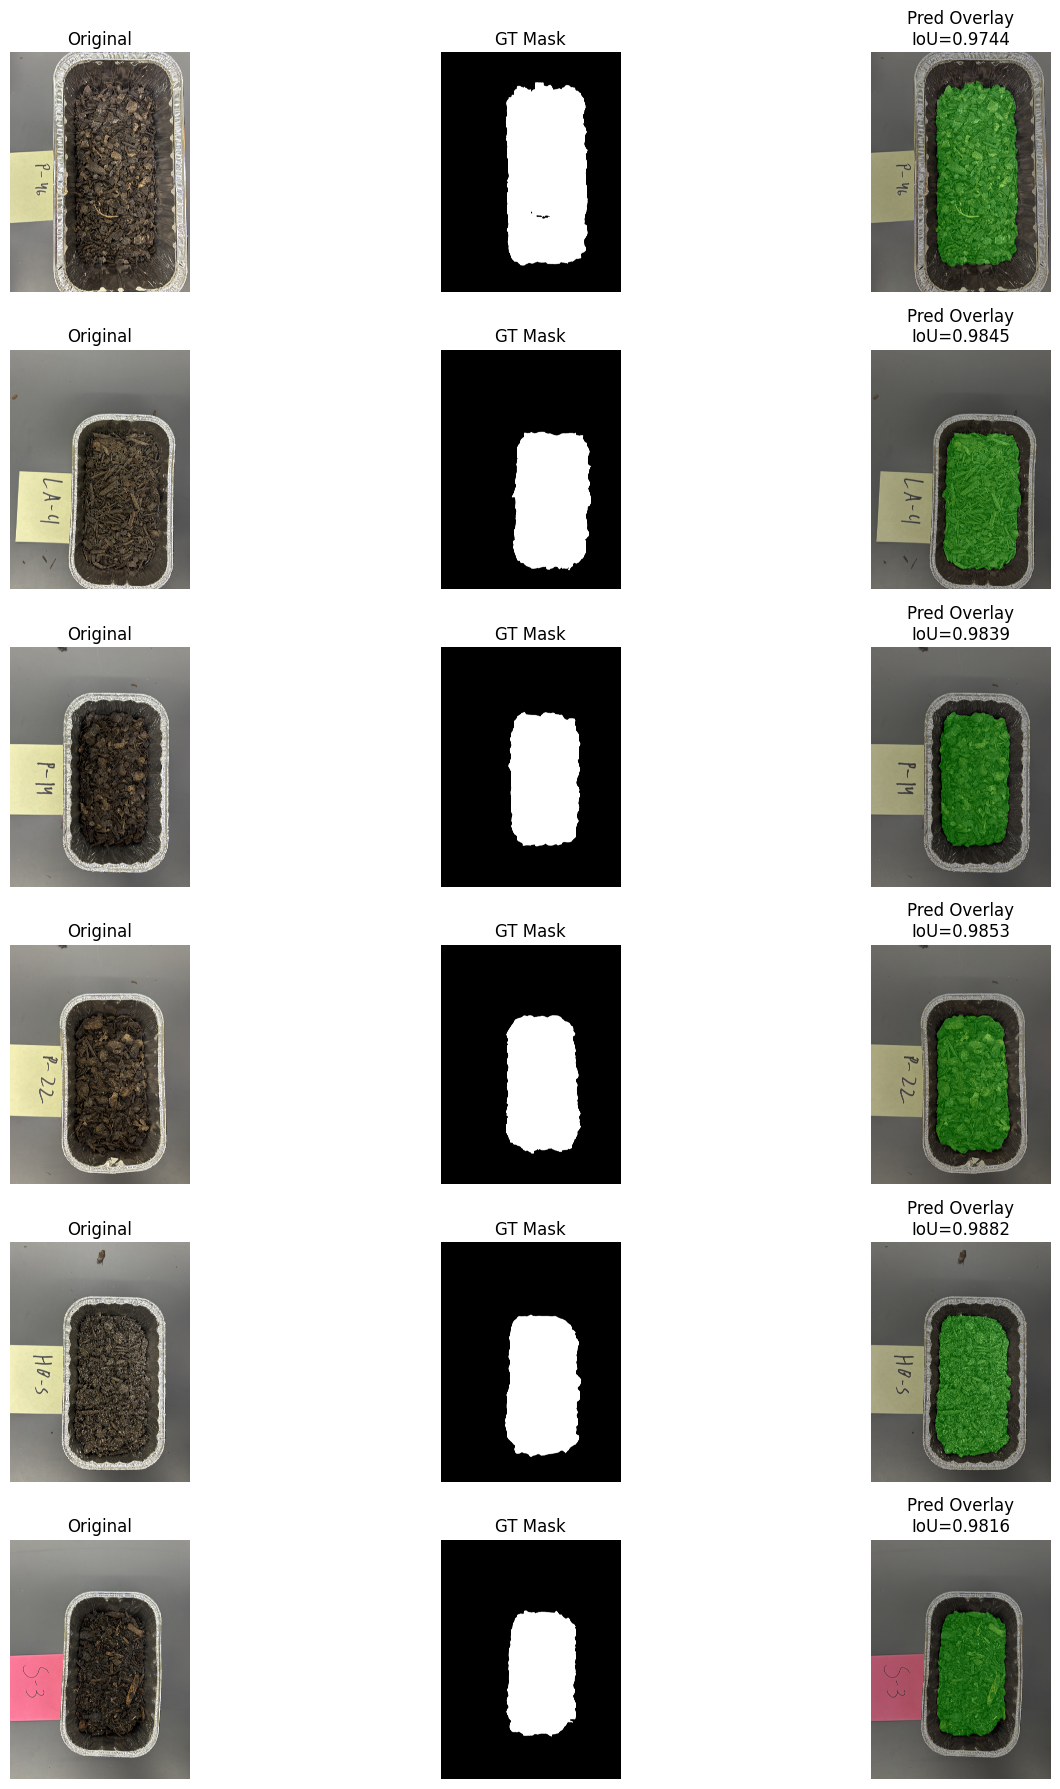

In [ ]:
# Visualizing predictions on a few validation images
import random, numpy as np, matplotlib.pyplot as plt, cv2, torch

def preprocess_for_infer(img_path, size=512):
    img = cv2.imread(img_path)
    if img is None:
        raise RuntimeError(f"Failed to read {img_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img_rgb.shape[:2]
    img_resized = cv2.resize(img_rgb, (size, size))
    inp = img_resized.astype("float32")/255.0
    # normalize (same as training)
    mean = np.array([0.485,0.456,0.406])
    std  = np.array([0.229,0.224,0.225])
    inp = (inp - mean)/std
    inp = np.transpose(inp, (2,0,1))[None,:,:,:]  # 1,3,H,W
    return img_rgb, (orig_h, orig_w), torch.from_numpy(inp).float()

def read_mask_original(mask_path):
    m = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if m is None:
        raise RuntimeError(f"Failed to read {mask_path}")
    if m.ndim == 3:
        m_bin = (m.sum(axis=2) > 0).astype(np.uint8)
    else:
        m_bin = (m > 0).astype(np.uint8)
    return m_bin  

def compute_iou_np(pred_mask, true_mask, eps=1e-7):
    pred = (pred_mask>0.5).astype(np.uint8)
    true = (true_mask>0).astype(np.uint8)
    inter = (pred & true).sum()
    union = (pred | true).sum()
    if union == 0:
        return 1.0 if inter == 0 else 0.0
    return (inter + eps) / (union + eps)

n_show = 6
if 'valid_pairs' not in globals():
    raise RuntimeError("valid_pairs not found. Make sure you created dataset split earlier and 'valid_pairs' exists.")
samples = random.sample(valid_pairs, min(n_show, len(valid_pairs)))

plt.figure(figsize=(15, n_show*3))
for i, (img_p, mask_p) in enumerate(samples, 1):
    orig_img, (oh, ow), inp = preprocess_for_infer(img_p, size=512)
    inp = inp.to(next(model.parameters()).device)  # ensure same device as model
    with torch.no_grad():
        logits = model(inp)
        prob = torch.sigmoid(logits)[0,0].cpu().numpy()  # 512 x 512

    pred_mask_orig = cv2.resize((prob*255).astype('uint8'), (ow, oh), interpolation=cv2.INTER_LINEAR)
    pred_mask_bin = (pred_mask_orig > 127).astype(np.uint8)

    true_mask_orig = read_mask_original(mask_p)
    if true_mask_orig.shape != (oh, ow):
        true_mask_orig = cv2.resize(true_mask_orig.astype('uint8'), (ow, oh), interpolation=cv2.INTER_NEAREST)
        true_mask_orig = (true_mask_orig > 0).astype(np.uint8)

    # compute IoU
    iou = compute_iou_np(pred_mask_bin, true_mask_orig)

    # create overlay
    overlay = orig_img.copy()
    color_mask = np.zeros_like(overlay)
    color_mask[:,:,1] = pred_mask_bin * 255  # green channel
    overlay = cv2.addWeighted(overlay, 0.7, color_mask, 0.3, 0)

    # Display: Original, GT mask, Overlay
    plt.subplot(n_show, 3, 3*(i-1)+1); plt.imshow(orig_img); plt.axis('off'); plt.title("Original")
    plt.subplot(n_show, 3, 3*(i-1)+2); plt.imshow(true_mask_orig, cmap='gray'); plt.axis('off'); plt.title("GT Mask")
    plt.subplot(n_show, 3, 3*(i-1)+3); plt.imshow(overlay); plt.axis('off'); plt.title(f"Pred Overlay\nIoU={iou:.4f}")

plt.tight_layout()
plt.show()



In [ ]:
# Full-dataset metrics
import os, glob, re, csv, json, cv2, numpy as np, torch, segmentation_models_pytorch as smp
from tqdm import tqdm
from pathlib import Path

# CONFIG - adjust if needed
CHECKPOINT_DIR = "/content/drive/MyDrive/Compost_checkpoints"
OUT_DIR = "/content/drive/MyDrive/Compost_metrics"
CSV_OUT = os.path.join(OUT_DIR, "per_image_metrics.csv")
SUMMARY_OUT = os.path.join(OUT_DIR, "summary.json")
IMAGE_SIZE = 512
THRESHOLD = 0.5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(OUT_DIR, exist_ok=True)

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

if 'pairs' in globals():
    data_pairs = pairs
elif 'valid_pairs' in globals():
    data_pairs = valid_pairs
else:
    raise RuntimeError("No 'pairs' or 'valid_pairs' found in notebook scope. Create the list of (img_path, mask_path) first.")

print(f"Found {len(data_pairs)} image-mask pairs for evaluation.")

ckpt_candidates = glob.glob(os.path.join(CHECKPOINT_DIR, "best_unfrozen_*.pth"))
if len(ckpt_candidates) == 0:
    ckpt_candidates = glob.glob(os.path.join(CHECKPOINT_DIR, "best_frozen_*.pth"))
if len(ckpt_candidates) == 0:
    raise RuntimeError(f"No best checkpoints found in {CHECKPOINT_DIR}. Please provide one.")

def parse_iou(fn):
    m = re.search(r"iou([0-9]+\.[0-9]+)", fn)
    return float(m.group(1)) if m else -1.0

best_ckpt = max(ckpt_candidates, key=parse_iou)
print("Using checkpoint:", best_ckpt)

model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1, activation=None)
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model = model.to(DEVICE)
model.eval()

MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
STD  = np.array([0.229,0.224,0.225], dtype=np.float32)

def preprocess_image(img_path, size=IMAGE_SIZE):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise RuntimeError(f"Failed to read image {img_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img_rgb.shape[:2]
    img_resized = cv2.resize(img_rgb, (size, size))
    inp = img_resized.astype(np.float32) / 255.0
    inp = (inp - MEAN) / STD
    inp = np.transpose(inp, (2,0,1))[None,:,:,:]  # 1,3,H,W
    return img_rgb, (orig_h, orig_w), torch.from_numpy(inp).float()

def read_true_mask(mask_path):
    m = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if m is None:
        raise RuntimeError(f"Failed to read mask {mask_path}")
    if m.ndim == 3:
        m_bin = (m.sum(axis=2) > 0).astype(np.uint8)
    else:
        m_bin = (m > 0).astype(np.uint8)
    return m_bin

def resize_prob_to_orig(prob_2d, orig_w, orig_h):
    prob_u8 = (prob_2d * 255.0).clip(0,255).astype(np.uint8)
    prob_resized = cv2.resize(prob_u8, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
    return (prob_resized.astype(np.float32) / 255.0)

def compute_confusion(pred_bin, true_bin):
    pred = pred_bin.astype(np.bool_)
    true = true_bin.astype(np.bool_)
    TP = int(np.logical_and(pred, true).sum())
    FP = int(np.logical_and(pred, np.logical_not(true)).sum())
    FN = int(np.logical_and(np.logical_not(pred), true).sum())
    TN = int(np.logical_and(np.logical_not(pred), np.logical_not(true)).sum())
    return TP, FP, FN, TN

def compute_metrics_from_conf(TP, FP, FN, TN, eps=1e-7):
    precision = (TP + eps) / (TP + FP + eps)
    recall = (TP + eps) / (TP + FN + eps)
    iou = (TP + eps) / (TP + FP + FN + eps)
    dice = (2*TP + eps) / (2*TP + FP + FN + eps)
    return precision, recall, iou, dice

rows = []
sum_tp = sum_fp = sum_fn = sum_tn = 0
ious = []
dices = []
precisions = []
recalls = []

for img_path, mask_path in tqdm(data_pairs, desc="Eval"):
    orig_img, (oh, ow), inp = preprocess_image(img_path, size=IMAGE_SIZE)
    inp = inp.to(DEVICE)
    with torch.no_grad():
        logits = model(inp)               
        prob = torch.sigmoid(logits)[0,0].cpu().numpy()  

    prob_orig = resize_prob_to_orig(prob, orig_w=ow, orig_h=oh)
    pred_bin = (prob_orig >= THRESHOLD).astype(np.uint8)

    true_mask = read_true_mask(mask_path)
    if true_mask.shape != (oh, ow):
        true_mask = cv2.resize(true_mask.astype(np.uint8), (ow, oh), interpolation=cv2.INTER_NEAREST)
        true_mask = (true_mask > 0).astype(np.uint8)

    TP, FP, FN, TN = compute_confusion(pred_bin, true_mask)
    prec, rec, iou, dice = compute_metrics_from_conf(TP, FP, FN, TN)
    rows.append({
        "image": os.path.basename(img_path),
        "img_path": img_path,
        "mask_path": mask_path,
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "precision": float(prec),
        "recall": float(rec),
        "iou": float(iou),
        "dice": float(dice)
    })
    sum_tp += TP; sum_fp += FP; sum_fn += FN; sum_tn += TN
    ious.append(iou); dices.append(dice); precisions.append(prec); recalls.append(rec)

# Saving CSV
with open(CSV_OUT, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["image","img_path","mask_path","TP","FP","FN","TN","precision","recall","iou","dice"])
    writer.writeheader()
    for r in rows:
        writer.writerow(r)

import statistics
micro_prec, micro_rec, micro_iou, micro_dice = compute_metrics_from_conf(sum_tp, sum_fp, sum_fn, sum_tn)
macro_iou = float(np.mean(ious)) if len(ious)>0 else 0.0
macro_dice = float(np.mean(dices)) if len(dices)>0 else 0.0

summary = {
    "n_images": len(rows),
    "micro_TP": int(sum_tp), "micro_FP": int(sum_fp), "micro_FN": int(sum_fn), "micro_TN": int(sum_tn),
    "micro_precision": float(micro_prec), "micro_recall": float(micro_rec),
    "micro_iou": float(micro_iou), "micro_dice": float(micro_dice),
    "macro_iou_mean": float(np.mean(ious)) if ious else None,
    "macro_iou_std": float(np.std(ious)) if ious else None,
    "macro_dice_mean": float(np.mean(dices)) if dices else None,
    "macro_dice_std": float(np.std(dices)) if dices else None,
    "macro_precision_mean": float(np.mean(precisions)) if precisions else None,
    "macro_recall_mean": float(np.mean(recalls)) if recalls else None,
    "threshold": THRESHOLD,
    "image_size_for_inference": IMAGE_SIZE,
    "checkpoint_used": best_ckpt
}

with open(SUMMARY_OUT, "w") as f:
    json.dump(summary, f, indent=2)

# Print summary
print("Saved per-image CSV to:", CSV_OUT)
print("Saved summary JSON to:", SUMMARY_OUT)
print("\nSummary metrics:")
for k,v in summary.items():
    print(f"{k}: {v}")

print("\nHuman-friendly overall metrics:")
print(f"Images evaluated: {summary['n_images']}")
print(f"Mean IoU (macro): {summary['macro_iou_mean']:.4f} ± {summary['macro_iou_std']:.4f}")
print(f"Mean Dice (macro): {summary['macro_dice_mean']:.4f} ± {summary['macro_dice_std']:.4f}")
print(f"Micro IoU: {summary['micro_iou']:.4f}")
print(f"Micro Dice: {summary['micro_dice']:.4f}")
print(f"Micro Precision: {summary['micro_precision']:.4f}")
print(f"Micro Recall: {summary['micro_recall']:.4f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 199 image-mask pairs for evaluation.
Using checkpoint: /content/drive/MyDrive/Compost_checkpoints/best_unfrozen_epoch2_iou0.9787.pth


Eval: 100%|██████████| 199/199 [04:34<00:00,  1.38s/it]

Saved per-image CSV to: /content/drive/MyDrive/Compost_metrics/per_image_metrics.csv
Saved summary JSON to: /content/drive/MyDrive/Compost_metrics/summary.json

Summary metrics:
n_images: 199
micro_TP: 1028483626
micro_FP: 11842904
micro_FN: 8609164
micro_TN: 3820635698
micro_precision: 0.9886161665030305
micro_recall: 0.99169875243275
micro_iou: 0.9805020764218555
micro_dice: 0.9901550602696811
macro_iou_mean: 0.9802620657505123
macro_iou_std: 0.008216966284181565
macro_dice_mean: 0.9900147941379682
macro_dice_std: 0.0043078312728505085
macro_precision_mean: 0.9886707427661663
macro_recall_mean: 0.9914180623438276
threshold: 0.5
image_size_for_inference: 512
checkpoint_used: /content/drive/MyDrive/Compost_checkpoints/best_unfrozen_epoch2_iou0.9787.pth

Human-friendly overall metrics:
Images evaluated: 199
Mean IoU (macro): 0.9803 ± 0.0082
Mean Dice (macro): 0.9900 ± 0.0043
Micro IoU: 0.9805
Micro Dice: 0.9902
Micro Precision: 0.9886
Micro Recall: 0.9917
